# PSL Performance Analytics

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [22]:
df = pd.read_csv(r"C:\Users\Abdul\OneDrive\Documents\Python\Session 10\ipl_player_performance.csv")
df.head()

,Match_ID,Player,Team,Runs,Balls,Strike_Rate,Wickets,Venue
0,M00001,Ravindra Jadeja,CSK,62,20,310.00,2,Wankhede
1,M00002,KL Rahul,LSG,45,17,264.71,3,Chinnaswamy
2,M00003,Jasprit Bumrah,MI,36,4,900.00,1,Chepauk
3,M00004,Virat Kohli,RCB,34,38,89.47,0,Chinnaswamy
4,M00005,Rohit Sharma,MI,8,21,38.10,0,Chinnaswamy


In [35]:
top_runs = df.groupby('Player')['Runs'].sum().nlargest(10)

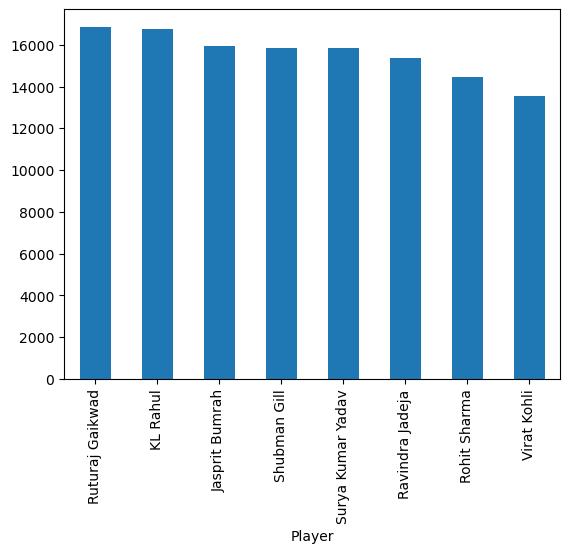

In [36]:
top_runs.plot(kind='bar')
plt.show()

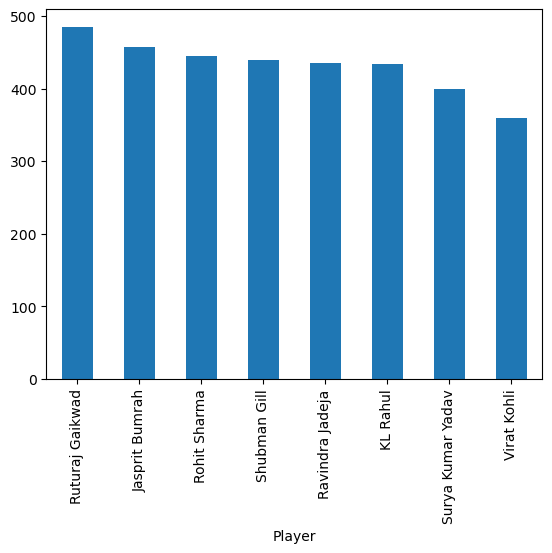

In [37]:
top_wickets = df.groupby('Player')['Wickets'].sum().nlargest(10)
top_wickets.plot(kind='bar')
plt.show()

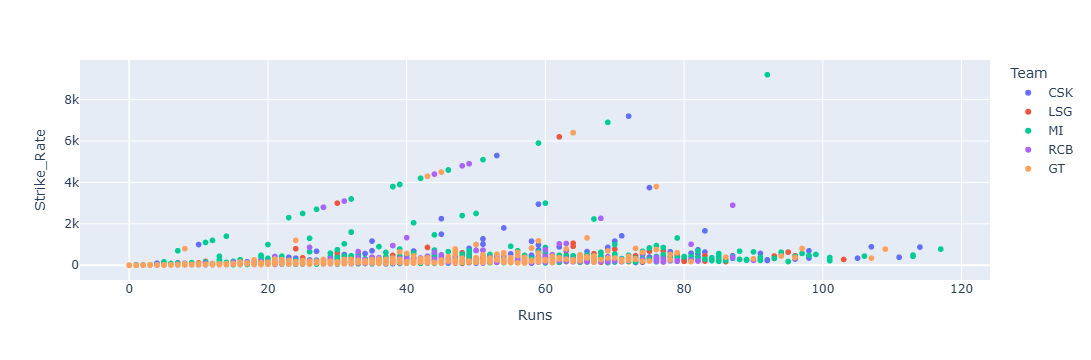

In [38]:
px.scatter(df, x='Runs', y='Strike_Rate', color='Team')

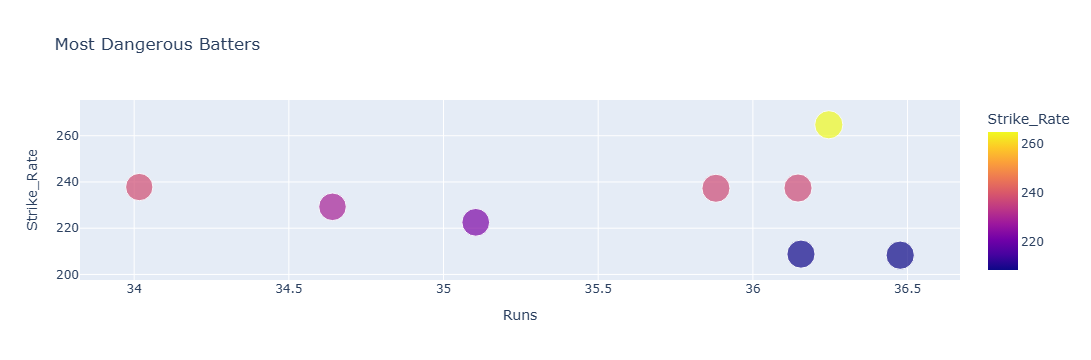

In [39]:
player_stats = (
    df.groupby("Player")
    .agg({
        "Runs":"mean",
        "Strike_Rate":"mean"
    })
    .reset_index())

fig = px.scatter(
    player_stats,
    x="Runs",
    y="Strike_Rate",
    size="Runs",
    color="Strike_Rate",
    hover_name="Player",
    title="Most Dangerous Batters")

fig.show()

In [8]:
team_runs = (
    df.groupby(["Team","Player"])["Runs"]
    .sum()
    .reset_index())

fig = px.sunburst(
    team_runs,
    path=["Team","Player"],
    values="Runs",
    title="Team Dependency Analysis")

fig.show()

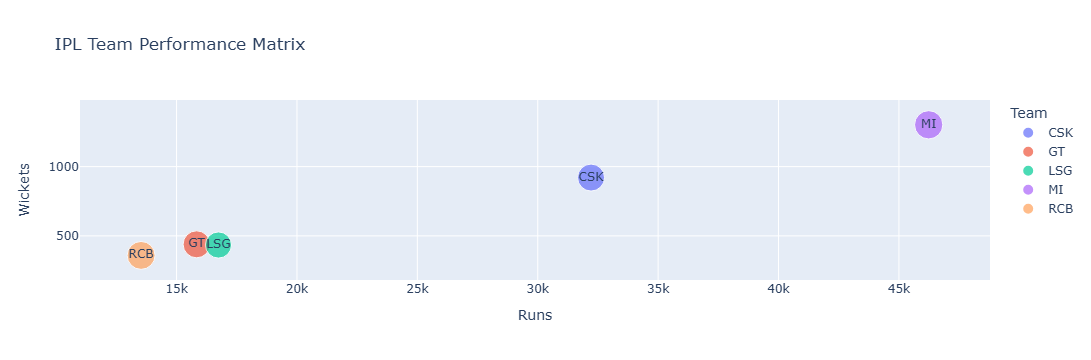

In [40]:
team_stats = (
    df.groupby("Team")
    .agg({
        "Runs":"sum",
        "Wickets":"sum",
        "Strike_Rate":"mean"
    })
    .reset_index())

fig = px.scatter(
    team_stats,
    x="Runs",
    y="Wickets",
    size="Strike_Rate",
    color="Team",
    text="Team",
    title="IPL Team Performance Matrix")

fig.show()